In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from matplotlib.patches import Ellipse
from scipy import stats

In [3]:
def draw_box(ax, *, x, dx, value, text, **kwargs):
    kwargs = (
        dict(
            shading="flat",
            edgecolors="black",
            linewidth=1,
        )
        | kwargs
    )
    ax.pcolormesh([x, x + dx], [0, 1], [[value]], **kwargs)
    ax.text(x + dx / 2, 0.5, text, va="center", ha="center")


def panel_A(fig):
    hspace = 0.4
    axes = fig.subplots(
        8, sharex=True, height_ratios=[1, hspace, 1, 1, hspace, 1, hspace, 1]
    )
    for ax in axes[[1, 4, 6]]:
        ax.axis(False)
    seaborn.despine(fig, bottom=True, left=True)
    for ax, title in zip(
        axes,
        [
            "Signal",
            "",
            "Average",
            "Difference",
            "",
            "Thresholded\nDifference",
            "",
            "Denoised",
        ],
    ):
        ax.text(-0.02, 0.5, title, transform=ax.transAxes, va="center", ha="right")
        ax.set(xticks=(), yticks=())

    x = np.array([1, 7, 2, 4, 5, 7])

    a = (x[1::2] + x[::2]) / 2
    d = (x[1::2] - x[::2]) / 2

    d_threshold = np.where(np.abs(d) < 2, 0, d)

    y = np.empty_like(x)
    y[::2] = a - d_threshold
    y[1::2] = a + d_threshold

    cmap = "Blues"
    norm = plt.Normalize(0, 10)

    for i, value in enumerate(x):
        draw_box(
            ax=axes[0], x=i, dx=1, value=value, text=f"$x_{i}$", norm=norm, cmap=cmap
        )

    dy = 2
    for i in range(a.size):
        xi = 2 * i + 0.5
        axes[1].arrow(xi + 0.5, 1.5, 0.5, dy)
        axes[1].arrow(xi + 0.5, 1.5, -0.5, dy)
        draw_box(
            ax=axes[2], x=xi, dx=1, value=a[i], text=f"$a_{i}$", norm=norm, cmap=cmap
        )
        draw_box(
            ax=axes[3],
            x=xi,
            dx=1,
            value=d[i],
            text=f"$d_{i}$",
            norm=plt.Normalize(0, 5),
            cmap="Reds",
        )
        draw_box(
            ax=axes[5],
            x=xi,
            dx=1,
            value=d_threshold[i],
            text=f"$d_{i}$",
            norm=plt.Normalize(0, 5),
            cmap="Reds",
        )

    draw_box(ax=axes[-1], x=0, dx=1, value=y[0], text=f"$x_0$", norm=norm, cmap=cmap)
    draw_box(ax=axes[-1], x=1, dx=1, value=y[1], text=f"$x_1$", norm=norm, cmap=cmap)
    draw_box(ax=axes[-1], x=2, dx=2, value=y[2], text=f"$a_1$", norm=norm, cmap=cmap)
    draw_box(ax=axes[-1], x=4, dx=2, value=y[4], text=f"$a_2$", norm=norm, cmap=cmap)


def colorbar_difference(fig):
    from matplotlib.cm import ScalarMappable

    cbar = fig.colorbar(
        ScalarMappable(norm=plt.Normalize(0, 5), cmap="Reds"),
        cax=fig.add_axes([0, 0.3, 0.05, 0.4]),
    )
    ticks = {
        5: "different",
        0: "equal",
        2: "threshold",
    }
    cbar.set_ticks(list(ticks.keys()))
    cbar.set_ticklabels(list(ticks.values()))

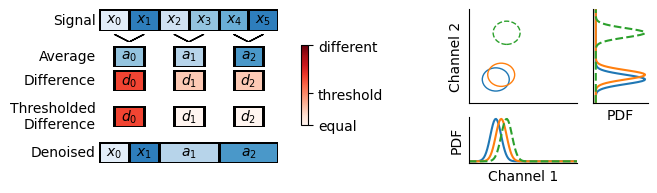

In [5]:
def panel_B(fig):
    # Create axes
    ratio = 2
    gs = plt.GridSpec(2, 2, width_ratios=[ratio, 1], height_ratios=[ratio, 1])
    ax2d = fig.add_subplot(gs[0, 0])
    ax_x = fig.add_subplot(gs[1, 0])
    ax_y = fig.add_subplot(gs[0, 1])

    # Plot
    t = np.linspace(-5, 15, 100)

    def add_point(x, y, sx, sy, color, **style):
        scale = 2 * stats.chi.ppf(stats.chi.cdf([2], df=1), df=2)
        for s in scale:
            ax2d.add_patch(
                Ellipse(
                    (x, y),
                    s * sx,
                    s * sy,
                    facecolor="none",
                    edgecolor=color,
                    **style
                )
            )
        ax_x.plot(t, stats.norm.pdf(t, loc=x, scale=sx), color=color, **style)
        ax_y.plot(stats.norm.pdf(t, loc=y, scale=sy), t, color=color, **style)

    add_point(x=0, y=0, sx=1, sy=1, color="C0")
    add_point(x=1, y=1, sx=1, sy=1, color="C1")
    add_point(x=2, y=10, sx=1, sy=1, color="C2", linestyle="--")

    # Style axes
    xlim = (t[0], t[-1])
    ylim = (t[0], t[-1])
    ax2d.set(xlim=xlim, ylim=ylim, ylabel="Channel 2")
    ax_x.set(xlim=xlim, xlabel="Channel 1", ylabel="PDF")
    ax_y.set(ylim=ylim, xlabel="PDF")
    for ax in (ax2d, ax_x, ax_y):
        ax.set(xticks=(), yticks=())
    seaborn.despine(fig)


fig = plt.figure(figsize=(6, 2))
figs = fig.subfigures(ncols=3, width_ratios=[1, 0.6, 1])
panel_A(figs[0])
colorbar_difference(figs[1])
panel_B(figs[2])

path = "../article/figures/1_diagram"
fig.savefig(path + ".png", bbox_inches="tight")
fig.savefig(path + ".pdf", bbox_inches="tight")